In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
input_path = f"/Users/athmiha/Desktop/final report/rf_test_preds_final.csv"

df_test = pd.read_csv(input_path)
display(df_test.head(10))
print(df_test.shape)

input_path_2 = f"/Users/athmiha/Desktop/final report/rf_val_preds_final.csv"

df_val = pd.read_csv(input_path_2)
display(df_val.head(10))
print(df_val.shape)

,start_interval,entries,excluded_roadway_entries,predicted_entries,predicted_excluded_roadway_entries,entries_residual,excluded_roadway_entries_residual
0,2025-09-26 00:20:00,9,0,6.231250,0.000035,2.768750,-0.000035
1,2025-09-26 00:20:00,75,91,74.354485,99.038536,0.645515,-8.038536
2,2025-09-26 00:20:00,14,0,15.371775,0.000527,-1.371775,-0.000527
3,2025-09-26 00:20:00,81,1,84.718110,3.571884,-3.718109,-2.571884
4,2025-09-26 00:20:00,152,0,157.597440,0.000000,-5.597443,0.000000
5,2025-09-26 00:20:00,120,0,138.856000,0.000000,-18.856003,0.000000
6,2025-09-26 00:20:00,133,50,98.157400,48.127514,34.842598,1.872486
7,2025-09-26 00:20:00,7,0,2.460307,0.001875,4.539693,-0.001875
8,2025-09-26 00:20:00,169,0,158.203520,0.000474,10.796478,-0.000474
9,2025-09-26 00:20:00,199,0,212.907930,0.000000,-13.907928,0.000000


(58968, 7)


,start_interval,entries,excluded_roadway_entries,predicted_entries,predicted_excluded_roadway_entries,entries_residual,excluded_roadway_entries_residual
0,2025-09-18 03:30:00,0,0,0.222302,0.000000,-0.222302,0.000000
1,2025-09-18 03:30:00,2,0,2.569074,0.000000,-0.569074,0.000000
2,2025-09-18 03:30:00,0,0,0.453062,0.000000,-0.453062,0.000000
3,2025-09-18 03:30:00,0,0,0.417738,0.010042,-0.417738,-0.010042
4,2025-09-18 03:30:00,0,0,0.726794,0.038514,-0.726794,-0.038514
5,2025-09-18 03:30:00,0,0,1.263398,0.000000,-1.263398,0.000000
6,2025-09-18 03:30:00,0,0,0.760740,0.142220,-0.760740,-0.142220
7,2025-09-18 03:30:00,1,0,0.606169,0.006165,0.393831,-0.006165
8,2025-09-18 03:30:00,1,0,0.861004,0.000000,0.138996,0.000000
9,2025-09-18 03:30:00,1,0,1.442047,0.000000,-0.442047,0.000000


(58968, 7)


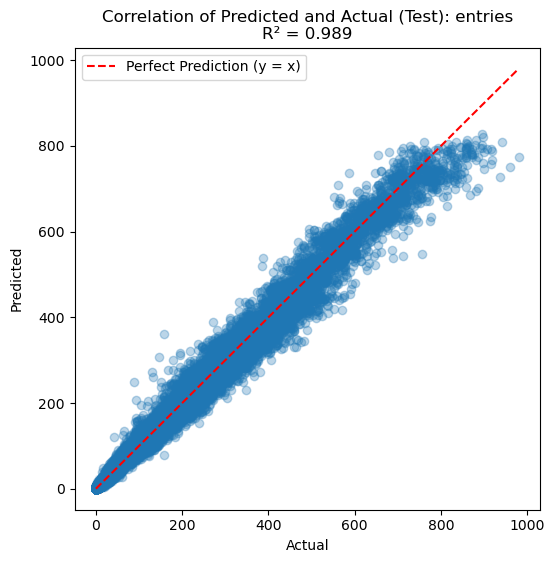

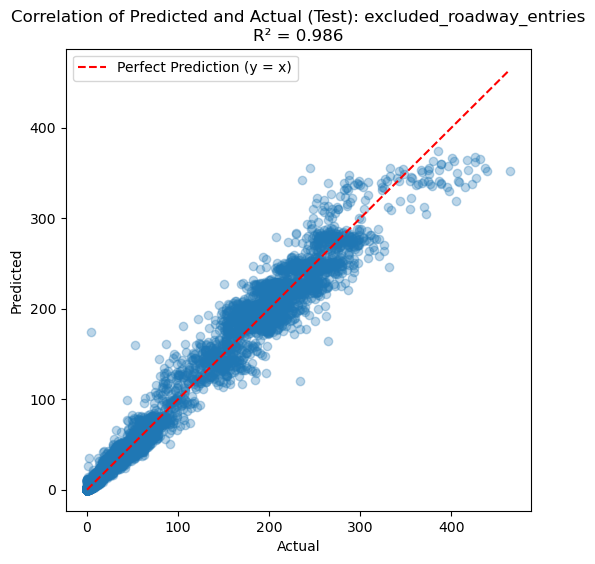

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# --- Load CSV ---
input_path = "/Users/athmiha/Desktop/final report/rf_test_preds_final.csv"
df_preds = pd.read_csv(input_path)

# Target and predicted columns
target_cols = ["entries", "excluded_roadway_entries"]
pred_cols = ["predicted_entries", "predicted_excluded_roadway_entries"]

# Plot correlation for each target
for col, pred_col in zip(target_cols, pred_cols):
    plt.figure(figsize=(6, 6))
    plt.scatter(df_preds[col], df_preds[pred_col], alpha=0.3)

    # Plot y = x line
    min_val = min(df_preds[col].min(), df_preds[pred_col].min())
    max_val = max(df_preds[col].max(), df_preds[pred_col].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect Prediction (y = x)")

    # Compute R²
    r2_val = r2_score(df_preds[col], df_preds[pred_col])

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Correlation of Predicted and Actual (Test): {col}\nR² = {r2_val:.3f}")
    plt.legend()
    plt.show()


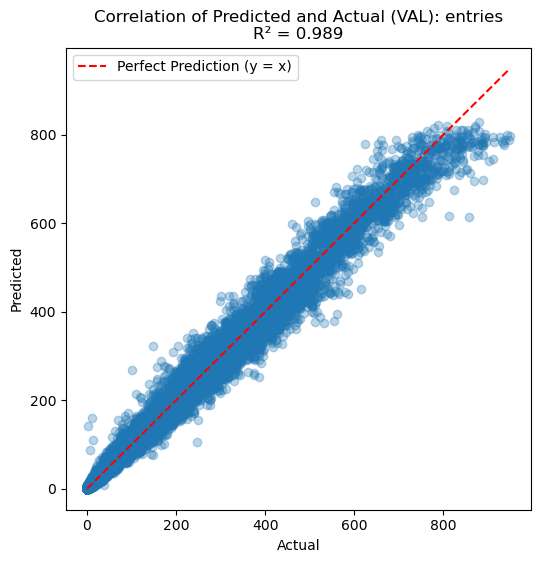

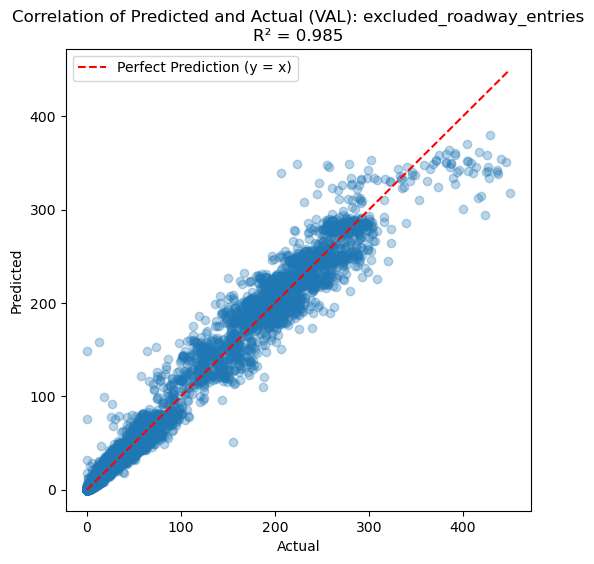

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# --- Load CSV ---
input_path = "/Users/athmiha/Desktop/final report/rf_val_preds_final.csv"
df_preds = pd.read_csv(input_path)

# Target and predicted columns
target_cols = ["entries", "excluded_roadway_entries"]
pred_cols = ["predicted_entries", "predicted_excluded_roadway_entries"]

# Plot correlation for each target
for col, pred_col in zip(target_cols, pred_cols):
    plt.figure(figsize=(6, 6))
    plt.scatter(df_preds[col], df_preds[pred_col], alpha=0.3)

    # Plot y = x line
    min_val = min(df_preds[col].min(), df_preds[pred_col].min())
    max_val = max(df_preds[col].max(), df_preds[pred_col].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect Prediction (y = x)")

    # Compute R²
    r2_val = r2_score(df_preds[col], df_preds[pred_col])

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Correlation of Predicted and Actual (VAL): {col}\nR² = {r2_val:.3f}")
    plt.legend()
    plt.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go

# --- Load CSV ---
input_path = "/Users/athmiha/Desktop/final report/rf_test_preds_final.csv"
df_test_preds = pd.read_csv(input_path)

# Ensure datetime format
df_test_preds["start_interval"] = pd.to_datetime(df_test_preds["start_interval"])

entries_time_test = (
    df_test_preds.groupby("start_interval", as_index=False)[
        ["entries", "predicted_entries"]
    ]
    .sum()
    .sort_values("start_interval")
)

fig = go.Figure()

# Actual 
fig.add_trace(go.Scatter(
    x=entries_time_test["start_interval"],
    y=entries_time_test["entries"],
    mode="lines+markers",
    name="Actual Entries",
    line=dict(color="steelblue", width=2)
))

# Predicted 
fig.add_trace(go.Scatter(
    x=entries_time_test["start_interval"],
    y=entries_time_test["predicted_entries"],
    mode="lines+markers",
    name="Predicted Entries",
    line=dict(color="tomato", width=2, dash="dash")
))

# Layout
fig.update_layout(
    title="Predicted vs Actual Entries Over Time (Test Set)",
    xaxis_title="Start Interval",
    yaxis_title="Entries",
    hovermode="x unified",
    template="plotly_white",
    legend=dict(
        title="Series",
        orientation="h",
        yanchor="bottom", y=-0.25,
        xanchor="center", x=0.5
    ),
    height=500,
    width=900
)

fig.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go

# --- Load CSV ---
input_path = "/Users/athmiha/Desktop/final report/rf_val_preds_final.csv"
df_test_preds = pd.read_csv(input_path)


df_test_preds["start_interval"] = pd.to_datetime(df_test_preds["start_interval"])

# Group by time and sum values
entries_time_test = (
    df_test_preds.groupby("start_interval", as_index=False)[
        ["entries", "predicted_entries"]
    ]
    .sum()
    .sort_values("start_interval")
)

# Create plot
fig = go.Figure()

# Actual entries
fig.add_trace(go.Scatter(
    x=entries_time_test["start_interval"],
    y=entries_time_test["entries"],
    mode="lines+markers",
    name="Actual Entries",
    line=dict(color="steelblue", width=2)
))

# Predicted entries
fig.add_trace(go.Scatter(
    x=entries_time_test["start_interval"],
    y=entries_time_test["predicted_entries"],
    mode="lines+markers",
    name="Predicted Entries",
    line=dict(color="tomato", width=2, dash="dash")
))

# Layout
fig.update_layout(
    title="Predicted vs Actual Entries Over Time (Val Set)",
    xaxis_title="Start Interval",
    yaxis_title="Entries",
    hovermode="x unified",
    template="plotly_white",
    legend=dict(
        title="Series",
        orientation="h",
        yanchor="bottom", y=-0.25,
        xanchor="center", x=0.5
    ),
    height=500,
    width=900
)

fig.show()


In [9]:
import pandas as pd
import plotly.graph_objects as go

# --- Load CSV ---
input_path = "/Users/athmiha/Desktop/final report/rf_test_preds_final.csv"
df_test_preds = pd.read_csv(input_path)

# Ensure datetime format
df_test_preds["start_interval"] = pd.to_datetime(df_test_preds["start_interval"])

# Group by time and sum values
excluded_time_test = (
    df_test_preds.groupby("start_interval", as_index=False)[
        ["excluded_roadway_entries", "predicted_excluded_roadway_entries"]
    ]
    .sum()
    .sort_values("start_interval")
)

# Create plot
fig = go.Figure()

# Actual excluded entries
fig.add_trace(go.Scatter(
    x=excluded_time_test["start_interval"],
    y=excluded_time_test["excluded_roadway_entries"],
    mode="lines+markers",
    name="Actual Excluded Entries",
    line=dict(color="steelblue", width=2)
))

# Predicted excluded entries
fig.add_trace(go.Scatter(
    x=excluded_time_test["start_interval"],
    y=excluded_time_test["predicted_excluded_roadway_entries"],
    mode="lines+markers",
    name="Predicted Excluded Entries",
    line=dict(color="tomato", width=2, dash="dash")
))

# Layout
fig.update_layout(
    title="Predicted vs Actual Excluded Entries Over Time (Test Set)",
    xaxis_title="Start Interval",
    yaxis_title="Excluded Entries",
    hovermode="x unified",
    template="plotly_white",
    legend=dict(
        title="Series",
        orientation="h",
        yanchor="bottom", y=-0.25,
        xanchor="center", x=0.5
    ),
    height=500,
    width=900
)

fig.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go

# --- Load CSV ---
input_path = "/Users/athmiha/Desktop/final report/rf_val_preds_final.csv"
df_test_preds = pd.read_csv(input_path)

df_test_preds["start_interval"] = pd.to_datetime(df_test_preds["start_interval"])

excluded_time_test = (
    df_test_preds.groupby("start_interval", as_index=False)[
        ["excluded_roadway_entries", "predicted_excluded_roadway_entries"]
    ]
    .sum()
    .sort_values("start_interval")
)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=excluded_time_test["start_interval"],
    y=excluded_time_test["excluded_roadway_entries"],
    mode="lines+markers",
    name="Actual Excluded Entries",
    line=dict(color="steelblue", width=2)
))

fig.add_trace(go.Scatter(
    x=excluded_time_test["start_interval"],
    y=excluded_time_test["predicted_excluded_roadway_entries"],
    mode="lines+markers",
    name="Predicted Excluded Entries",
    line=dict(color="tomato", width=2, dash="dash")
))

fig.update_layout(
    title="Predicted vs Actual Excluded Entries Over Time (Val Set)",
    xaxis_title="Start Interval",
    yaxis_title="Excluded Entries",
    hovermode="x unified",
    template="plotly_white",
    legend=dict(
        title="Series",
        orientation="h",
        yanchor="bottom", y=-0.25,
        xanchor="center", x=0.5
    ),
    height=500,
    width=900
)

fig.show()


In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- Load test predictions ---
input_path = "/Users/athmiha/Desktop/final report/rf_test_preds_final.csv"
df_test_preds = pd.read_csv(input_path)

# Target columns and their predictions
target_cols = ["entries", "excluded_roadway_entries"]
pred_cols = ["predicted_entries", "predicted_excluded_roadway_entries"]

# Compute metrics
metrics_list = []

for target, pred in zip(target_cols, pred_cols):
    for split in ["Test"]:  # here only using Test set
        y_true = df_test_preds[target]
        y_pred = df_test_preds[pred]

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        mean_y = y_true.mean()

        metrics_list.append({
            "Set": split,
            "Target": target,
            "RMSE % mean": rmse / mean_y * 100,
            "MAE % mean": mae / mean_y * 100
        })

metrics_df = pd.DataFrame(metrics_list)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=["RMSE as % of Mean", "MAE as % of Mean"]
)

# RMSE % mean chart
for target in metrics_df["Target"].unique():
    df_sub = metrics_df[metrics_df["Target"] == target]
    fig.add_trace(
        go.Bar(
            x=df_sub["Set"],
            y=df_sub["RMSE % mean"],
            name=f"{target} (RMSE)",
            text=[f"{v:.1f}%" for v in df_sub["RMSE % mean"]],
            textposition="outside"
        ),
        row=1, col=1
    )

# MAE % mean chart
for target in metrics_df["Target"].unique():
    df_sub = metrics_df[metrics_df["Target"] == target]
    fig.add_trace(
        go.Bar(
            x=df_sub["Set"],
            y=df_sub["MAE % mean"],
            name=f"{target} (MAE)",
            text=[f"{v:.1f}%" for v in df_sub["MAE % mean"]],
            textposition="outside"
        ),
        row=1, col=2
    )

# Layout
fig.update_layout(
    title_text="RF Test Set Performance (RMSE and MAE as % of Mean)",
    barmode="group",
    legend_title_text="Target",
    height=500,
    width=1000,
    uniformtext_minsize=8,
    uniformtext_mode="hide",
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.update_xaxes(showgrid=True, gridcolor="lightgray")
fig.update_yaxes(title_text="Error (% of Mean)", showgrid=True, gridcolor="lightgray")

fig.show()


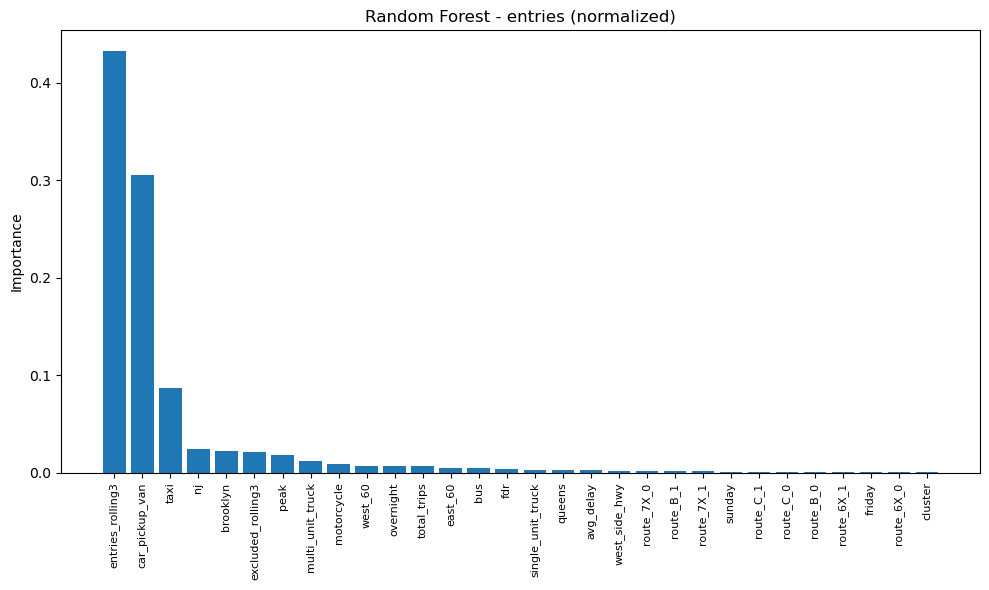

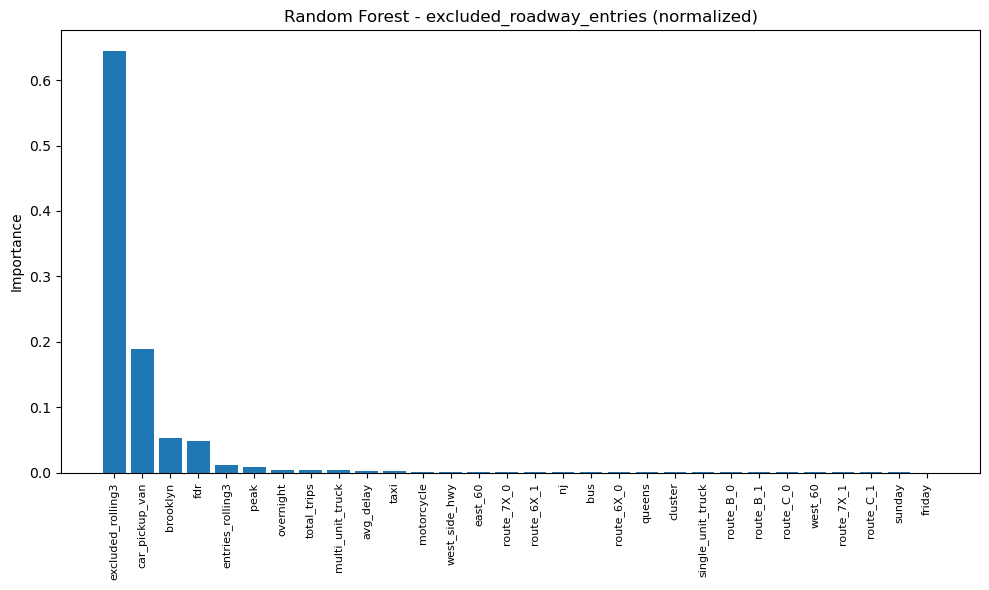

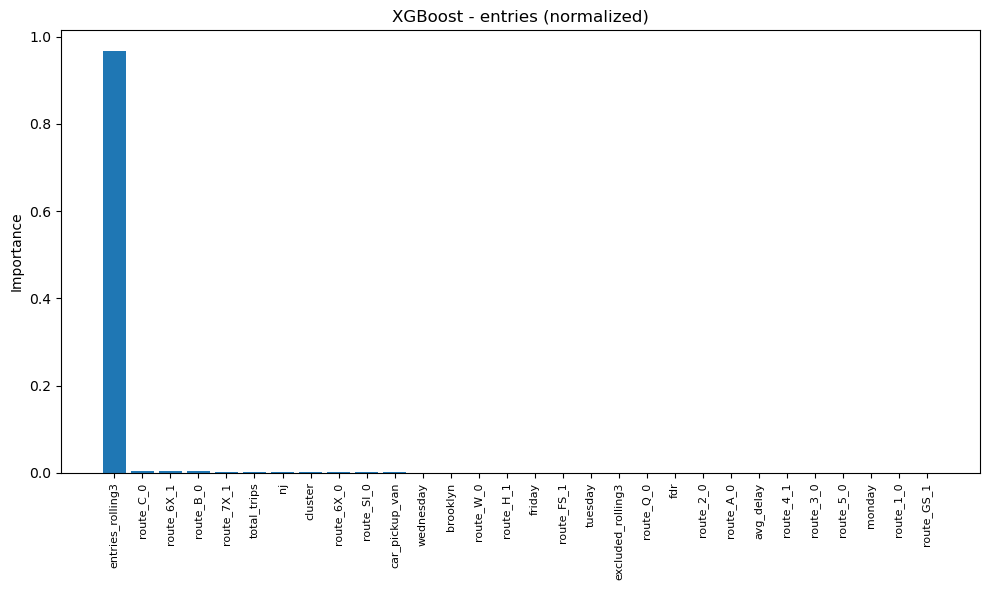

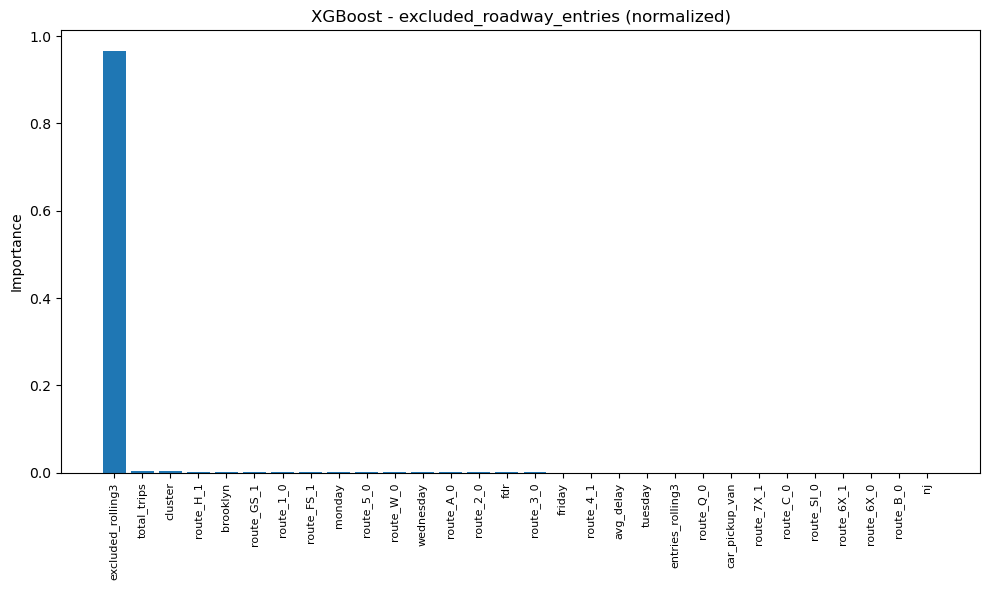

Plotted top features for RF and XGB


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths
rf_path = "/Users/athmiha/Desktop/final report/rf_feature_importances.csv"
xgb_path = "/Users/athmiha/Desktop/final report/xgb_feature_importances.csv"

top_n = 30
normalize = True
sort_by = "sum"
log_scale = False

def load_importances_try(path_or_df):
    """
    Accepts a path or a DataFrame. Returns DataFrame with columns ['feature','importance'].
    """
    if isinstance(path_or_df, pd.DataFrame):
        df = path_or_df.copy()
    else:
        df = pd.read_csv(path_or_df)
    
    cols_lower = {c.lower(): c for c in df.columns}
    
    f_cands = ["feature","features","index","name"]
    imp_cands = ["importance","imp","gain","weight","cover",
                 "feature_importance","importance_xgb","importance_rf",
                 "entries","excluded_roadway_entries"]
    
    feature_col = None
    imp_cols = []
    
    for c in f_cands:
        if c in cols_lower:
            feature_col = cols_lower[c]
            break
    if feature_col is None:
        feature_col = df.columns[0]

    
    for nc in df.select_dtypes(include=[np.number]).columns:
        if nc != feature_col:
            imp_cols.append(nc)
    
    if not imp_cols:
        raise ValueError(f"No numeric importance columns found in {path_or_df}")
    
    out = df[[feature_col] + imp_cols].copy()
    out.columns = ["feature"] + imp_cols
    out["feature"] = out["feature"].astype(str)
    for col in imp_cols:
        out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0.0)
    
    return out

# Load
rf = load_importances_try(rf_path)
xgb = load_importances_try(xgb_path)


if normalize:
    for col in rf.columns[1:]:
        s = rf[col].sum()
        if s > 0:
            rf[col] = rf[col] / s
    for col in xgb.columns[1:]:
        s = xgb[col].sum()
        if s > 0:
            xgb[col] = xgb[col] / s


rf["importance_sum"] = rf.iloc[:, 1:].abs().sum(axis=1)
xgb["importance_sum"] = xgb.iloc[:, 1:].abs().sum(axis=1)

rf_top = rf.sort_values("importance_sum", ascending=False).head(top_n)
xgb_top = xgb.sort_values("importance_sum", ascending=False).head(top_n)

def plot_importances(df, col, model_name):

    df_sorted = df.sort_values(col, ascending=False)

    features = df_sorted["feature"]
    values = df_sorted[col]

    plt.figure(figsize=(10, max(6, len(features)*0.18)))
    plt.bar(np.arange(len(features)), values)
    plt.xticks(np.arange(len(features)), features, rotation=90, fontsize=8)
    plt.title(f"{model_name} - {col}" + (" (normalized)" if normalize else ""))
    plt.ylabel("Importance")
    
    if log_scale:
        plt.yscale("log")

    plt.tight_layout()
    plt.show()


# Plot RF
for col in ["entries", "excluded_roadway_entries"]:
    if col in rf_top.columns:
        plot_importances(rf_top, col, "Random Forest")

# Plot XGB
for col in ["entries", "excluded_roadway_entries"]:
    if col in xgb_top.columns:
        plot_importances(xgb_top, col, "XGBoost")

print("Plotted top features for RF and XGB")
